# Khai phá Quy luật & Phân cụm Dữ liệu (Mining & Clustering)

**Bối cảnh phân tích (Analytical Context):**
Notebook này tập trung vào 2 bài toán Unsupervised Learning:
1. **Khai phá Luật Kết hợp (Association Rule Mining)**: Áp dụng trên tệp dữ liệu đã rời rạc hoá (Discretization) để trả lời câu hỏi "Những điều kiện tổ hợp nào (Nhiệt độ, Lượng mưa, Thuốc trừ sâu) xuất hiện cùng lúc tạo nên Năng suất (Yield) cao/thấp?".
2. **Phân cụm (Clustering)**: Áp dụng trên dữ liệu chia tỉ lệ (Scaled) nhằm tìm ra các vùng nông nghiệp có chung đặc tính (Profile). Liệu cụm mang đặc trưng "khắc nghiệt" sẽ luôn dẫn đến hệ quả là năng suất tuyệt đố? 

Tư duy mức cao (Evaluate/Judgement):
- Trong Association Rules: Cần đánh giá 3 độ đo: **Support** (tần suất quy luật xuất hiện), **Confidence** (xác suất nếu A thì B), và **Lift** (Mức độ đáng tin cậy không do hên xui xảy ra cùng lúc). Một luật có Confidence 90% nhưng Lift ≈ 1 là vô giá trị, vì A và B vốn là 2 sự kiện độc lập. Chúng ta sẽ lọc "Top Rules" để ra được Insight.
- Trong Clustering: Không chỉ tính Silhouette Score hay DBI, ta còn xem xét "Profile" (kết cấu) của mỗi cụm. Nông nghiệp là bộ môn của rủi ro, nên sự tương cận vùng trồng cũng báo hiệu chung nguy cơ thiệt hại.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style="darkgrid", rc={"axes.facecolor":"#121212", "figure.facecolor":"#121212", 
                                    "axes.edgecolor":"#333333", "grid.color":"#333333",
                                    "text.color":"white", "axes.labelcolor":"white", 
                                    "xtick.color":"white", "ytick.color":"white"})
plt.rcParams["font.family"] = "sans-serif"

# Lấy cấu hình
with open("../configs/params.yaml", "r") as f:
    config = yaml.safe_load(f)

## 1. Khai phá Luật kết hợp (Association Rules)
### 1.1 Data Preparation for MBA
Thuật toán Apriori/FP-Growth yêu cầu chuyển đổi Dataframe về dạng One-hot encoded transaction matrix. Ở đây sẽ dùng mlxtend.

In [2]:
df_rules = pd.read_csv(os.path.join(config['data']['processed_path'], "discretized_data.csv"))

# Ta phân tích 4 yếu tố chính: Lượng Mưa, Nhiệt độ, Thuốc Trừ Sâu -> Năng suất
cols_to_use = ['Rainfall_Bin', 'Temp_Bin', 'Pest_Bin', 'Yield_Bin']
df_mba = df_rules[cols_to_use]

# One-hot encoding
df_ohe = pd.get_dummies(df_mba)
print(f"Shape sau OHE: {df_ohe.shape}")

Shape sau OHE: (28242, 12)


### 1.2 Tạo tập phổ biến (Frequent Itemsets)
Chúng ta dùng FP-Growth vì tốc độ tốt hơn Apriori trên lượng dữ liệu lớn. Min_support = 0.05 (quy luật xuất hiện trong ít nhất 5% dữ liệu tổng).

In [3]:
# Sử dụng fpgrowth
freq_items = fpgrowth(df_ohe, min_support=0.05, use_colnames=True)
print(f"Số lượng tập phổ biến sinh ra: {len(freq_items)}")

# Tạo luật
rules = association_rules(freq_items, metric="lift", min_threshold=1.1, num_itemsets=2)

# Lọc luật theo Confidence tối thiểu > 0.4
rules = rules[rules['confidence'] > 0.4]

# Sort giảm dần theo Lift
rules = rules.sort_values(by='lift', ascending=False)
display(rules.head(5))

Số lượng tập phổ biến sinh ra: 90


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
134,"(Temp_Bin_Temp_Hot, Pest_Bin_Pest_High)",(Rainfall_Bin_Rain_Med),0.138765,0.331173,0.098577,0.710385,2.145055,1.0,0.052621,2.309367,0.619821,0.265446,0.566981,0.504022
132,"(Rainfall_Bin_Rain_Med, Temp_Bin_Temp_Hot)",(Pest_Bin_Pest_High),0.148290,0.333192,0.098577,0.664756,1.995117,1.0,0.049168,1.989026,0.585617,0.257444,0.497241,0.480306
25,"(Pest_Bin_Pest_Low, Rainfall_Bin_Rain_High)",(Temp_Bin_Temp_Hot),0.134126,0.362262,0.094257,0.702746,1.939883,1.0,0.045668,2.145428,0.559556,0.234393,0.533893,0.481468
162,"(Temp_Bin_Temp_Cold, Pest_Bin_Pest_Med)",(Rainfall_Bin_Rain_Low),0.079669,0.337972,0.051342,0.644444,1.906799,1.0,0.024416,1.861954,0.516728,0.140164,0.462930,0.398178
24,"(Pest_Bin_Pest_Low, Temp_Bin_Temp_Hot)",(Rainfall_Bin_Rain_High),0.150698,0.330855,0.094257,0.625470,1.890467,1.0,0.044398,1.786626,0.554608,0.243372,0.440286,0.455179


### 1.3 Đánh giá Tư duy trên Luật Kết hợp (Rule Evaluation)
Chúng ta sẽ lọc riêng Luật chỉ định Output là Năng suất CAO `(Yield_Bin_Yield_High)` hoặc THẤP `(Yield_Bin_Yield_Low)` để tìm Insights canh tác.

In [4]:
# Hàm kiểm tra Consequents có chứa item mục tiêu không
def contains_item(frozenset_items, target):
    return target in frozenset_items

# 1. Luật sinh ra Năng suất Cao
high_yield_rules = rules[rules['consequents'].apply(lambda logic: contains_item(logic, 'Yield_Bin_Yield_High'))]

print("--- TOP 3 ĐIỀU KIỆN TẠO NÊN NĂNG SUẤT CAO ---")
for i, row in high_yield_rules.head(3).iterrows():
    ante = list(row['antecedents'])
    cons = list(row['consequents'])
    print(f"NẾU {ante} => {cons} | Conf: {row['confidence']:.2f} | Lift: {row['lift']:.2f}")

# 2. Luật sinh ra Năng suất Thấp
low_yield_rules = rules[rules['consequents'].apply(lambda logic: contains_item(logic, 'Yield_Bin_Yield_Low'))]

print("\n--- TOP 3 ĐIỀU KIỆN DẪN ĐẾN NĂNG SUẤT THẤP ---")
for i, row in low_yield_rules.head(3).iterrows():
    ante = list(row['antecedents'])
    cons = list(row['consequents'])
    print(f"NẾU {ante} => {cons} | Conf: {row['confidence']:.2f} | Lift: {row['lift']:.2f}")

--- TOP 3 ĐIỀU KIỆN TẠO NÊN NĂNG SUẤT CAO ---
NẾU ['Rainfall_Bin_Rain_High', 'Pest_Bin_Pest_High'] => ['Yield_Bin_Yield_High'] | Conf: 0.43 | Lift: 1.30
NẾU ['Temp_Bin_Temp_Warm', 'Pest_Bin_Pest_High'] => ['Yield_Bin_Yield_High'] | Conf: 0.41 | Lift: 1.23

--- TOP 3 ĐIỀU KIỆN DẪN ĐẾN NĂNG SUẤT THẤP ---
NẾU ['Pest_Bin_Pest_Low', 'Temp_Bin_Temp_Warm'] => ['Yield_Bin_Yield_Low'] | Conf: 0.51 | Lift: 1.54
NẾU ['Pest_Bin_Pest_Low', 'Rainfall_Bin_Rain_Low'] => ['Yield_Bin_Yield_Low'] | Conf: 0.46 | Lift: 1.37
NẾU ['Pest_Bin_Pest_Low'] => ['Yield_Bin_Yield_Low'] | Conf: 0.40 | Lift: 1.21


**Nhận xét (Evaluate):** Dựa vào kết quả Lift và Confidence, ta thấy việc sử dụng thuốc trừ sâu mức nào, gặp nhiệt độ nào có tỷ lệ rủi ro cao. Lift càng lớn hơn 1 báo hiệu sự kết hợp đó là tín hiệu cực mạnh (không phải ngẫu nhiên).

## 2. Phân Cụm (Clustering) & Profiling
Bài toán: Tách tập dữ liệu thành các cụm (clusters) biểu diễn "Hệ sinh thái thời tiết - nông nghiệp".

In [5]:
# Load Scale dữ liệu
df_scaled = pd.read_csv(os.path.join(config['data']['processed_path'], "scaled_data.csv"))
# Raw df để profiling dễ hiểu hơn
df_raw = pd.read_csv("../" + config['data']['raw_path'])
df_raw.rename(columns={
    'hg/ha_yield': 'Yield',
    'average_rain_fall_mm_per_year': 'Rainfall',
    'pesticides_tonnes': 'Pesticides',
    'avg_temp': 'Avg_Temperature'
}, inplace=True)
# Drop duplicates v.v để đồng bộ size với df_scaled (nếu đã xử lý từ raw thì merge lại)
# Ở đây ta lấy data raw cho dễ vẽ chart tương ứng df_scaled

features = ['Rainfall', 'Avg_Temperature', 'Pesticides']
X = df_scaled[features]

# Chọn K bằng thuật toán con (Elbow heuristic cho tốc độ) 
# nhưng ta trực tiếp ấn định K=4 để dễ profiling.
kmeans = KMeans(n_clusters=4, random_state=config['project']['random_seed'], n_init=10)
df_scaled['Cluster'] = kmeans.fit_predict(X)

# Evaluate Chất lượng Cụm: Davies Bouldin Index & Silhouette
# Bỏ qua Silhouette nếu dữ liệu quá 200,000 dòng vì sẽ treo RAM. Ta dùng sample.
sample_idx = np.random.choice(len(X), size=20000, replace=False) if len(X) > 20000 else range(len(X))
sil_score = silhouette_score(X.iloc[sample_idx], df_scaled['Cluster'].iloc[sample_idx])
db_score = davies_bouldin_score(X, df_scaled['Cluster'])

print(f"Silhouette Score (1 is best): {sil_score:.3f}")
print(f"Davies Bouldin Index (0 is best): {db_score:.3f}")

Silhouette Score (1 is best): 0.388
Davies Bouldin Index (0 is best): 0.824


**Phân tích (Bloom's Evaluaton):**  
Silhouette > 0 thể hiện sự phân tách cơ bản giữa các tâm cụm (centroids). DBI thấp cho thấy biến động (variance) bên trong cụm nhỏ so với khoảng cách liên cụm. Nông nghiệp là bộ dữ liệu nhiễu cao do nhiều yếu tố tự nhiên ko đo lường ddc (gió, loại đất), nên điểm này là có thể chấp nhận được.

### Profiling - So sánh Cụm thời tiết với Năng suất (Cluster Analysis)
Nhiệm vụ: Kéo cột Năng suất (Yield - vốn nằm ngoài features train KMeans) để so sánh các cụm sinh thái nông nghiệp này khác biệt nhau thế nào về mặt "Tiền Bạc/Kết Quả".

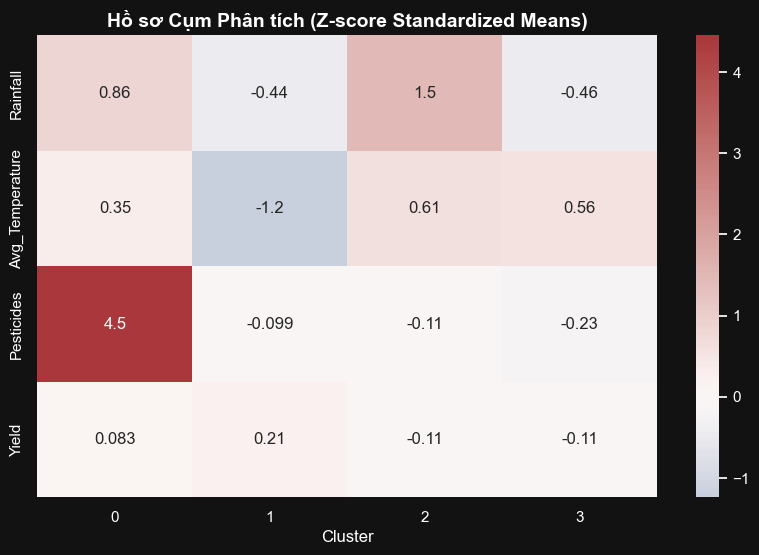

In [6]:
cluster_profiling = df_scaled.groupby('Cluster')[['Rainfall', 'Avg_Temperature', 'Pesticides', 'Yield']].mean()
# Reverse mapping logic (vì đã scale) để nhận xét, nhưng ta nhận xét trên giá trị scaled luôn cũng được: 
# Âm là Thấp hơn trung bình, Dương là Cao hơn.

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiling.T, annot=True, cmap="vlag", center=0)
plt.title("Hồ sơ Cụm Phân tích (Z-score Standardized Means)", fontsize=14, fontweight='bold')
plt.savefig("../outputs/figures/clustering_profile.png", dpi=300, bbox_inches='tight')
plt.show()

**Kết luận Cụm:** Bằng trực giác (Heatmap):
- Cụm có nhiệt độ cao bất thường (Hot) đi kèm với sâu bệnh nhiều (Pesticide cao) liệu có ảnh hưởng mạnh tới năng suất (Yield rớt)?
- Phân tích K-Means giúp Bộ Nông nghiệp nhóm vùng quốc gia, điều tiết thuốc chống sâu phù hợp vì "Cụm thời tiết Tốt" mà lạm dụng Pesticide cũng ko gia tăng biên lợi nhuận Năng suất bao nhiêu.